In [1]:
%matplotlib inline

import os

import pandas as pd
import multiprocessing
import sys, os, glob
from functools import partial
from astropy.io import fits, ascii

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('style.mplstyle')

from astropy import units as u
from astropy.table import Table
import astropy.constants as const
from astropy.coordinates import SkyCoord, concatenate
from astropy import table

import pandas as pd

from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM, w0waCDM, z_at_value

import scipy.stats as st
from scipy.optimize import minimize
import warnings
import h5py

In [2]:
bands = ['u', 'g', 'r', 'i', 'z']#, 'y']

def read_quasars_from_hdf5(file_path):
    quasar_list = []
    with h5py.File(file_path, "r") as hdf:
        for group_name in hdf.keys():
            group = hdf[group_name]
            quasar = {"object_id": group_name}
            for key, value in group.attrs.items():
                quasar[key] = value
            for sub_group_name in group.keys():
                sub_group = group[sub_group_name]
                quasar[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
            quasar_list.append(quasar)
    return quasar_list


quasar_list = read_quasars_from_hdf5("data/may4_objs_tauwavelength_merged.h5")
print("Number of quasars loaded:", len(quasar_list))

hdul = fits.open('data/dr16q_prop_May01_2024.fits')
fits_data = hdul[1].data  # Assuming the data is in the first extension    
fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    

def populate_sdss_fields(d):
    i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
    if len(i) == 0:
        print(f"Warning: {d['sdss_name']} not found in SDSS data")
        return d
    i = i[0]
    if np.any(fits_data_2['PSFFLUX'][i,:] <= 0):
        return d
    d['z_err'] = fits_data['Z_SYS_ERR'][i]
    d['log_mbh'] = fits_data['LOGMBH'][i]
    d['log_mbh_err'] = fits_data['LOGMBH_ERR'][i]
    d['log_ledd_ratio'] = fits_data['LOGLEDD_RATIO'][i]
    d['log_ledd_ratio_err'] = fits_data['LOGLEDD_RATIO_ERR'][i]
    d['ebv'] = fits_data['EBV'][i]
    d['M_i'] = fits_data_2['M_I'][i]
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        d['apparent_mag_z'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,4]) + 22.5
        d['apparent_mag_i'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,3]) + 22.5
        d['apparent_mag_r'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,2]) + 22.5
        d['apparent_mag_g'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,1]) + 22.5
        d['apparent_mag_u'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i,0]) + 22.5
        d['apparent_mag_z_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,4])/fits_data_2['PSFFLUX'][i,4]
        d['apparent_mag_i_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,3])/fits_data_2['PSFFLUX'][i,3]
        d['apparent_mag_r_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,2])/fits_data_2['PSFFLUX'][i,2]
        d['apparent_mag_g_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,1])/fits_data_2['PSFFLUX'][i,1]
        d['apparent_mag_u_err'] = 2.5/np.log(10) * np.sqrt(1/fits_data_2['PSFFLUX_IVAR'][i,0])/fits_data_2['PSFFLUX'][i,0]
        d['color'] = -2.5 * np.log10(fits_data_2['PSFFLUX'][i, 0] / fits_data_2['PSFFLUX'][i, 3])
    if any(issubclass(warning.category, RuntimeWarning) for warning in w):
        print(f"RuntimeWarning occurred for {d['sdss_name']}")
        print(fits_data_2['PSFFLUX'][i,:])
        print(w)
    return d

def calc_lam_RF(d):
    lam_pivot = {
        'V': 5477,  # Johnson (no direct SDSS equivalent)
        'B': 4353,  # Johnson (no direct SDSS equivalent)
        'R': 6580,  # SDSS r-band
        'g': 4770,  # SDSS g-band
        'r': 6231,  # SDSS r-band
        'i': 7625,  # SDSS i-band
        'z': 9134,  # SDSS z-band
        'u': 3543,  # SDSS u-band
        'y': 9633,  # PS1 y-band
        'TESS': 7865,  # TESS broadband filter
        'kepler': 6420,  # Kepler broadband filter
        '5100 AA': 5100  # Reference wavelength
    }
    # Compute rest-frame wavelength
    lam_pivots = lam_pivot['i']
    lam_RF = lam_pivots / (1 + d['z'])
    d['log_lambda_RF'] = np.log10(lam_RF)
    return d

def split_field_by_band_nm1(q, keys):
    clean_bands = q['clean_bands'][1:]
    for key in keys:
        try:
            for i, b in enumerate(clean_bands):
                q[f'{key}_{b}'] = q[key][i]
            for b in list(set(bands) - set(clean_bands)):
                q[f'{key}_{b}'] = -1
        except:
            print(f"{key=}, {b=}, {clean_bands=}, {i=}, {q['z']=} {q[key].shape=}")

def split_field_by_band(q, keys):
    clean_bands = q['clean_bands']
    for key in keys:
        try:
            for i, b in enumerate(clean_bands):
                q[f'{key}_{b}'] = q[key][i]
            for b in list(set(bands) - set(clean_bands)):
                q[f'{key}_{b}'] = -1
        except:
            print(f"{key=}, {b=}, {clean_bands=}, {i=}, {q['z']=} {q[key].shape=}")

for q in quasar_list:
    for b in q['magerrs'].keys():
        if len(q['magerrs'][b]) == 0:
            continue
        q[f'magerrs_mean_{b}'] = np.nanmean(q['magerrs'][b])
    split_field_by_band(q, ['log_sigma_band', 'log_sigma_band_err', 'log_jitter'])
    split_field_by_band_nm1(q, ['lag', 'lag_err', 'log_lag_blr', 'log_lag_blr_err'])

    populate_sdss_fields(q)
    calc_lam_RF(q)
    q['delta_time'] = q['times']['r'].max() - q['times']['r'].min()

df = pd.DataFrame(quasar_list)
#df = df.set_index('object_id')
#df = df.drop(columns=['log_jitter', 'magerrs_mean', 'log_sigma_band', 'log_sigma_band_err', 'clean_bands'])
df = df.drop(columns=['mags', 'times', 'magerrs'])

df_all = df.copy()

# Remove infinite values from numeric columns
columns_with_nans = df.columns[df.isna().any()].tolist()
print("Columns with NaNs:", columns_with_nans)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].where(~np.isinf(df[numeric_cols]), np.nan)
df = df.dropna()

for i, band in enumerate(bands):
    df = df[(df[f'log_sigma_band_{band}'] == -1) | ((10**df[f'log_sigma_band_{band}']) > 1.*np.sqrt(df[f'magerrs_mean_{band}']**2 + (10**df[f'log_jitter_{band}'])**2))]

df_original = df.copy()

print("Final number of quasars:", len(df))
df.head()
#df[['object_id']][:100].to_csv('data/df_quasars_filtered_apr27.csv', index=False)

Number of quasars loaded: 1914
key='lag', b='z', clean_bands=array(['z'], dtype=object), i=0, q['z']=np.float64(4.152862427931158) q[key].shape=()
key='lag_err', b='z', clean_bands=array(['z'], dtype=object), i=0, q['z']=np.float64(4.152862427931158) q[key].shape=()
key='lag', b='z', clean_bands=array(['z'], dtype=object), i=0, q['z']=np.float64(4.099991263829631) q[key].shape=()
key='lag_err', b='z', clean_bands=array(['z'], dtype=object), i=0, q['z']=np.float64(4.099991263829631) q[key].shape=()
key='lag', b='z', clean_bands=array(['z'], dtype=object), i=0, q['z']=np.float64(4.076981408039309) q[key].shape=()
key='lag_err', b='z', clean_bands=array(['z'], dtype=object), i=0, q['z']=np.float64(4.076981408039309) q[key].shape=()
Columns with NaNs: ['lag_g', 'lag_r', 'lag_i', 'lag_z', 'lag_u', 'lag_err_g', 'lag_err_r', 'lag_err_i', 'lag_err_z', 'lag_err_u']
Final number of quasars: 640


,object_id,beta,beta_err,clean_bands,dec,delta,delta_err,i,lag,lag_err,...,apparent_mag_g,apparent_mag_u,apparent_mag_z_err,apparent_mag_i_err,apparent_mag_r_err,apparent_mag_g_err,apparent_mag_u_err,color,log_lambda_RF,delta_time
7,1388428,-0.167858,0.094538,"[u, g, r, i, z]",0.380098,0.384165,0.064483,7,"[3.1466957676510527, 5.101065170053106, -22.33...","[5.007422574556907, 10.37837200009737, 18.9101...",...,19.419571,19.443937,0.037060,0.021654,0.020916,0.024838,0.030142,0.182863,3.753382,8068.003247
8,1388445,-0.202337,0.059923,"[u, g, r, i, z]",1.156838,0.391824,0.049768,8,"[2.354904550274732, -3.088051730039816, 0.5433...","[2.750056157859034, 3.501645304539101, 2.94791...",...,18.455492,18.639133,0.030172,0.014117,0.011099,0.023494,0.020719,0.233411,3.591278,7452.752323
14,1388513,-0.012612,0.062360,"[u, g, r, i, z]",-0.291992,0.228747,0.053452,14,"[-12.11066433845921, -4.777340064089218, -19.1...","[5.819434553021869, 5.201703634714803, 6.88332...",...,19.370337,19.480885,0.047305,0.025051,0.025908,0.020434,0.025819,0.398161,3.531204,8369.068557
16,1388637,-0.296226,0.077485,"[u, g, r, i, z]",-0.934498,0.344327,0.064823,16,"[14.575781222307478, 8.179698567101394, 0.6962...","[6.283267355212727, 6.431304873552361, 9.34089...",...,19.198532,19.333923,0.034857,0.023888,0.025172,0.029012,0.028076,0.535627,3.448151,8420.993226
19,1388651,0.037756,0.034601,"[u, g, r, i, z]",0.181636,0.361722,0.042317,19,"[13.976127007092405, 13.092531639954572, 7.566...","[6.879365827721187, 4.271588429073683, 1.65517...",...,19.785812,19.729168,0.066887,0.019918,0.020931,0.016139,0.031340,0.294734,3.550500,8369.068569


In [24]:
def drop_faintest_bin(df, z_col='z', mag_col='apparent_mag_i', z_bins_width=0.1, mag_margin=0.5):
    """
    Drop quasars within mag_margin magnitude of the faintest quasar in each redshift bin.

    Parameters:
        df (pd.DataFrame): Input dataframe containing redshifts and apparent magnitudes.
        z_col (str): Column name for redshift.
        mag_col (str): Column name for apparent magnitude.
        z_bins_width (float): Width of each redshift bin.
        mag_margin (float): Magnitude range to drop above the faintest object.

    Returns:
        pd.DataFrame: Filtered dataframe.
    """
    df = df.copy().reset_index(drop=True)

    # Create redshift bins
    z_min, z_max = df[z_col].min(), df[z_col].max()
    z_bins = np.arange(z_min, z_max + z_bins_width, z_bins_width)

    # Assign bin labels
    df['z_bin'] = pd.cut(df[z_col], bins=z_bins, include_lowest=True)

    # Container for indices to drop
    indices_to_drop = []

    # Iterate over each redshift bin
    for bin_interval, group in df.groupby('z_bin'):
        if len(group) == 0:
            continue
        faintest_mag = group[mag_col].max()  # Faintest magnitude (largest value)
        
        # Identify objects within mag_margin from the faintest magnitude
        drop_condition = group[mag_col] >= (faintest_mag - mag_margin)
        indices_to_drop.extend(group[drop_condition].index.tolist())

    # Drop identified indices
    filtered_df = df.drop(indices_to_drop).reset_index(drop=True)

    # Drop auxiliary bin column
    filtered_df = filtered_df.drop(columns='z_bin')

    return filtered_df

df = df_original.copy()

# data cuts
df = df[df['log_sigma_RF'] < 0]
df = df[df['log_tau_RF'] > 1.5]
df = df[df['log_lbol'] > 44]
df = df[df['log_mbh'] > 1]
df = df[df['ebv'] < 0.05]

#df = drop_faintest_bin(df, z_col='z', mag_col='apparent_mag_i', z_bins_width=0.1, mag_margin=0.5)

# df = df[np.abs(df['apparent_mag_i_err'] / df['apparent_mag_i']) < 0.01]
# df = df[np.abs(df['log_sigma_RF_err'] / df['log_sigma_RF']) < 0.3]
# df = df[np.abs(df['log_tau_RF_err'] / df['log_tau_RF']) < 0.2]
# df = df[np.abs(df['beta_err'] / df['beta']) < 0.5]
# df = df[np.abs(df['delta_err'] / df['delta']) < 0.5]


df.reset_index(drop=True)
#df = df_original.copy()
print(len(df))

634


In [4]:
url = 'https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true'
df_pantheon = pd.read_csv(url, delim_whitespace=True)
df_pantheon.keys()

/tmp/ipykernel_135306/2347323853.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_pantheon = pd.read_csv(url, delim_whitespace=True)


Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='object')

Number of parameters in MCMC: 6


/tmp/ipykernel_135306/2316756069.py:48: RuntimeWarning: divide by zero encountered in log
  ll_agn = np.sum(np.log(st.norm.pdf(dmu_agn, scale=mu_pred_agn_err))) #+ \
/tmp/ipykernel_135306/2316756069.py:48: RuntimeWarning: divide by zero encountered in log
  ll_agn = np.sum(np.log(st.norm.pdf(dmu_agn, scale=mu_pred_agn_err))) #+ \
/tmp/ipykernel_135306/2316756069.py:48: RuntimeWarning: divide by zero encountered in log
  ll_agn = np.sum(np.log(st.norm.pdf(dmu_agn, scale=mu_pred_agn_err))) #+ \
/tmp/ipykernel_135306/2316756069.py:48: RuntimeWarning: divide by zero encountered in log
  ll_agn = np.sum(np.log(st.norm.pdf(dmu_agn, scale=mu_pred_agn_err))) #+ \
/tmp/ipykernel_135306/2316756069.py:48: RuntimeWarning: divide by zero encountered in log
  ll_agn = np.sum(np.log(st.norm.pdf(dmu_agn, scale=mu_pred_agn_err))) #+ \
  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_135306/2316756069.py:48: RuntimeWarning: divide by zero encountered in log
  ll_agn = np.sum(np.log(st.norm.pdf(dmu

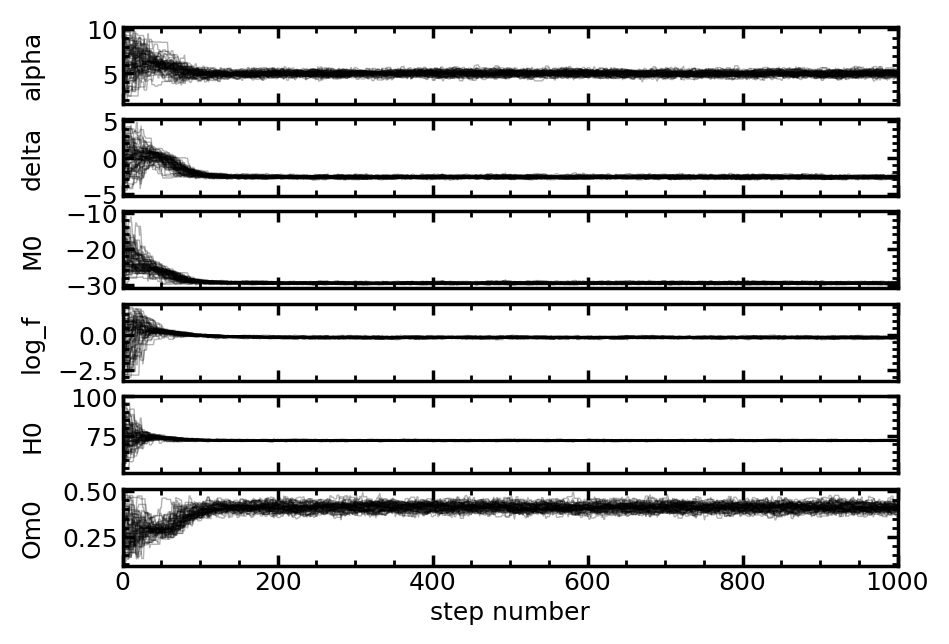

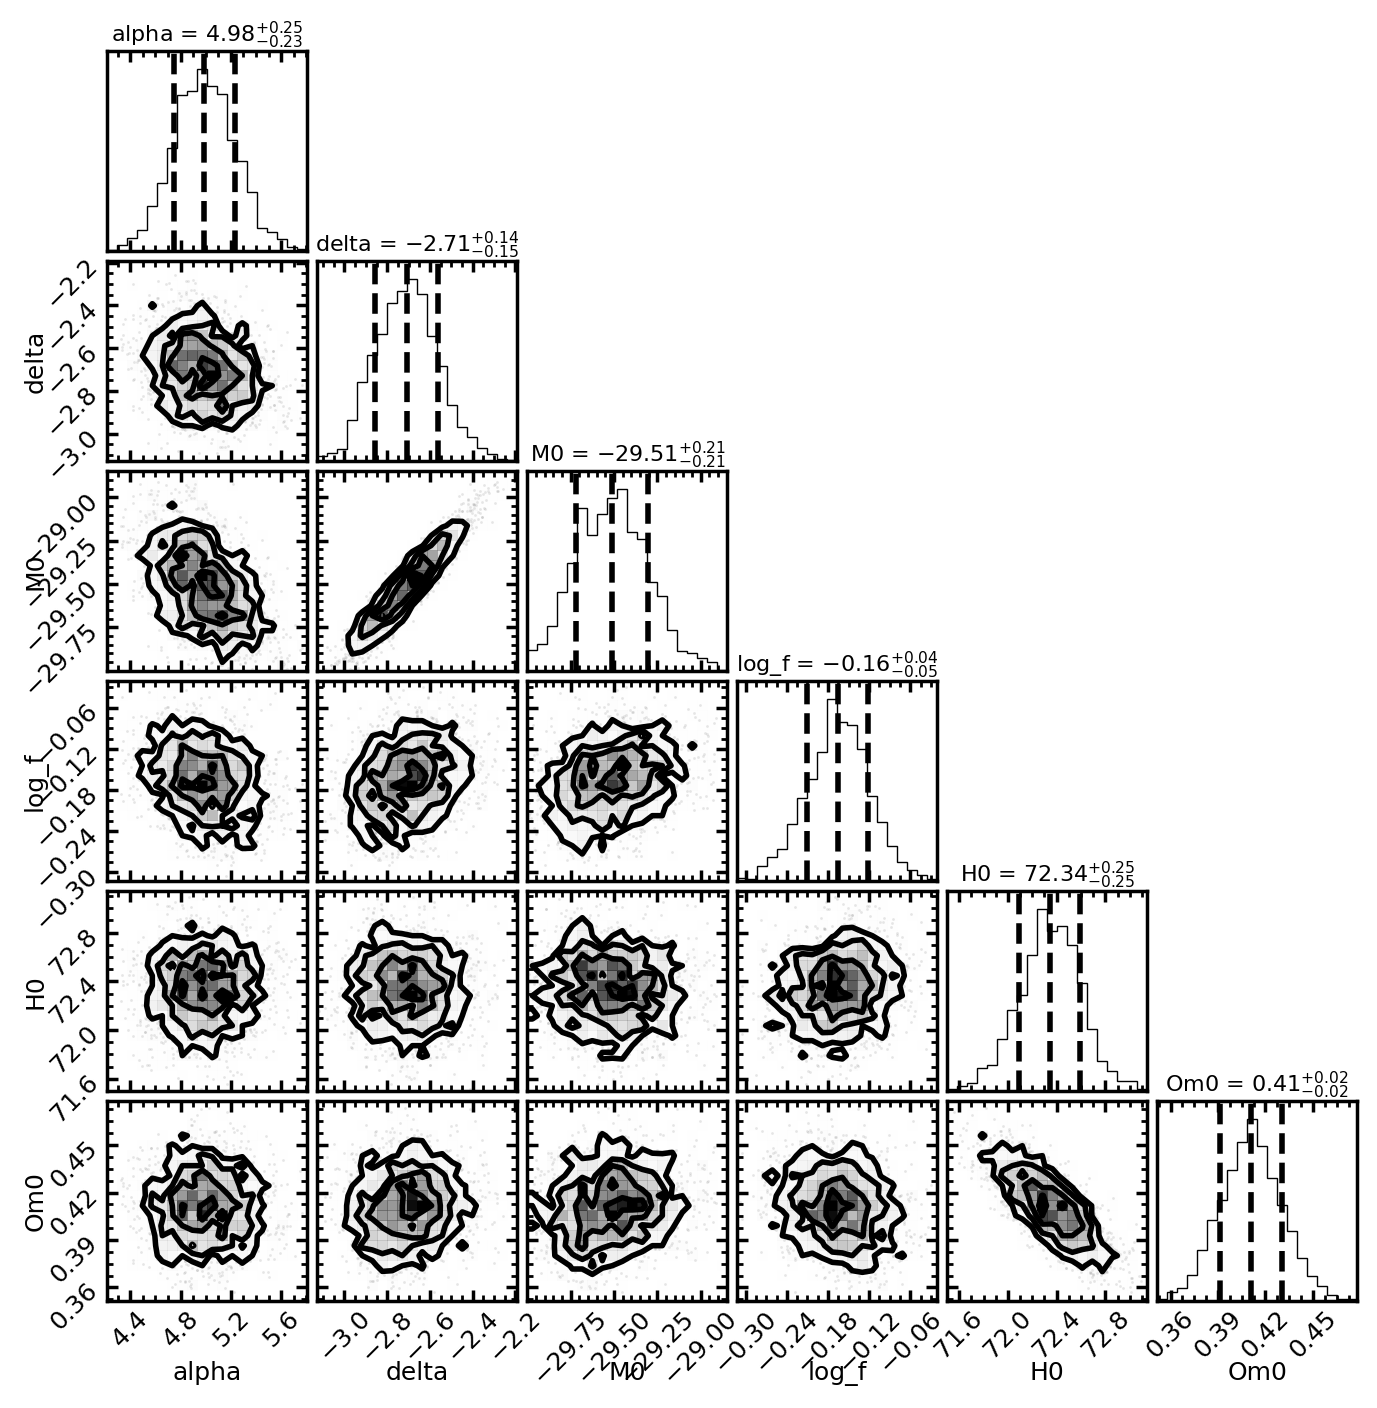

In [25]:
import emcee
import corner
import numpy as np
from astropy.cosmology import w0waCDM, FlatLambdaCDM
import matplotlib.pyplot as plt

#df = df[~df['apparent_mag_i'].between(19, 20)]

# --- Constants ---
z_pivot = df['z'].median()
sigma_pivot = -1.2
tau_pivot = 3.6

def M_model(M0, alpha, delta):
    return M0 + alpha * (df["log_sigma_RF"]-sigma_pivot) + delta * (df["log_tau_RF"]-tau_pivot)

def K_corr(z, alpha_nu=-0.5):
    return -2.5 * (1 + alpha_nu) * np.log10(1 + z)

# log_likelihood function
def log_likelihood(theta):

    alpha, delta, M0, log_f, H0, Om0 = theta

    # Prior
    for i, (key, val) in enumerate(priors.items()):
        lower, upper = val
        if not (lower < theta[i] < upper):
            return -np.inf

    #cosmo = w0waCDM(H0=H0, Om0=0.3, Ode0=1.0 - 0.3, w0=w0, wa=wa)
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    mu_model = cosmo.distmod(df['z']).value
    
    # Model distance modulus
    mu_pred_agn = df['apparent_mag_i'] - M_model(M0, alpha, delta) - K_corr(df['z'])

    # Model error
    mu_pred_agn_err = np.sqrt(df['apparent_mag_i_err']**2 + 
                          (alpha * df["log_sigma_RF_err"])**2 + 
                          (delta * df["log_tau_RF_err"])**2 +
                          (-2.5 * 0.3 * np.log10(1 + df["z"]))**2 + # K-correction error
                          (0.055 * df["z"])**2 + # lensing error
                          np.exp(2 * log_f))

    dmu_agn = mu_pred_agn - mu_model

    ll_agn = np.sum(np.log(st.norm.pdf(dmu_agn, scale=mu_pred_agn_err))) #+ \
            #np.sum(np.log(st.truncnorm.cdf(dmu_agn, scale=mu_pred_agn_err, a=-np.inf, b=dmu_lim))) #np.sum(np.log(I))

    # SNIa
    mu_model = cosmo.distmod(df_pantheon['zHD']).value
    mu_pred_snia = df_pantheon['MU_SH0ES']
    dmu_snia = mu_pred_snia - mu_model

    ll_snia = np.sum(np.log(st.norm.pdf(dmu_snia, scale=df_pantheon['MU_SH0ES_ERR_DIAG'])))
    #ll_snia = -0.5 * np.dot(dmu_snia, np.linalg.solve(covariance_matrix, dmu_snia)) #+ np.log(1/(2*np.pi * np.sqrt(np.linalg.det(covariance_matrix)))) # Slow

    return ll_snia + ll_agn

# Define a dictionary to hold model parameters
priors = {
    "alpha": (2, 10),
    "delta": (-5, 5),
    "M0": (-30, -10),
    "log_f": (-3, 2),
    # cosmology parameters
    "H0": (50, 100),
    "Om0": (0.1, 0.5),
    #"Ode0": (0.1, 0.9),
    #"w0": (-2, 2),
    #"wa": (-2, 2)
}

# Set up the sampler
ndim = len(priors)
nwalkers = 2*30
nsteps_burnin = 1000
nsteps_production = 1000

print(f"Number of parameters in MCMC: {ndim}")

# Run the MCMC sampler
ncpus = multiprocessing.cpu_count()  # or set manually
pool = multiprocessing.Pool(processes=ncpus-2)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, pool=pool)


# Initial positions of the walkers
initial_pos = np.array([np.random.uniform(low, high, nwalkers) for low, high in priors.values()]).T

state = sampler.run_mcmc(initial_pos, nsteps_burnin, progress=True)

# Extract the samples
samples_by_chain = sampler.get_chain()
#tau = sampler.get_autocorr_time()
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

labels = list(priors.keys())

fig, axes = plt.subplots(len(labels), figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples_by_chain[:, :, i], "k", alpha=0.3, lw=1)
    ax.set_xlim(0, len(samples_by_chain))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");
plt.show()

fig = corner.corner(flat_samples, show_titles=True, labels=labels, quantiles=[0.16, 0.5, 0.84],
                    label_kwargs=dict(fontsize=18), title_kwargs=dict(fontsize=16));
plt.show()

results = {key: np.percentile(flat_samples[:, i], [16, 50, 84]) for i, key in enumerate(priors.keys())}

/tmp/ipykernel_135306/515022882.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_pantheon = pd.read_csv(url, delim_whitespace=True)
/tmp/ipykernel_135306/515022882.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


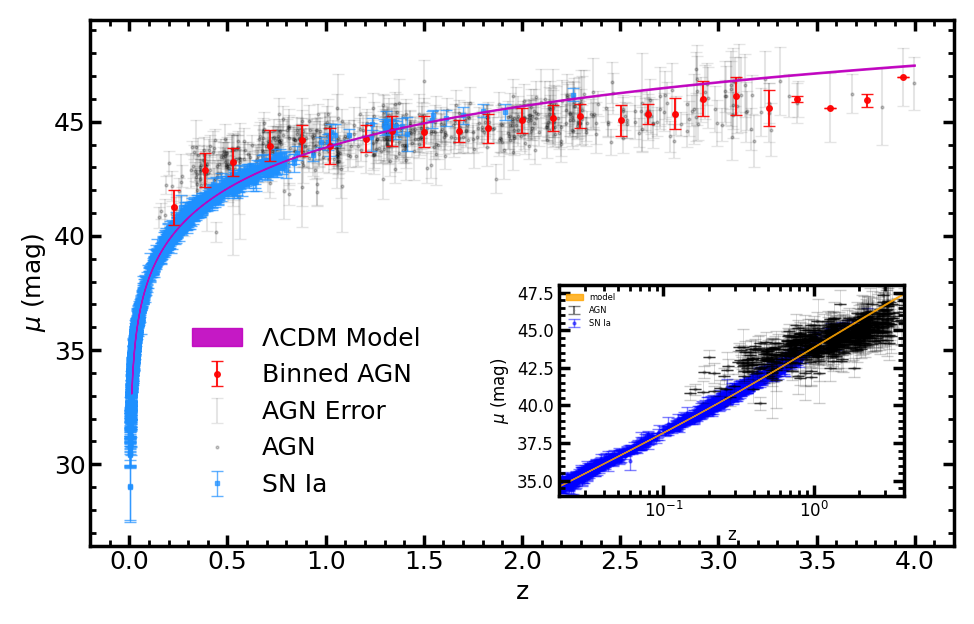

In [26]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

url = 'https://github.com/PantheonPlusSH0ES/DataRelease/blob/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat?raw=true'
df_pantheon = pd.read_csv(url, delim_whitespace=True)
df_pantheon

z_grid = np.linspace(0.01, 4.0, len(df))


#mu_models = np.array([w0waCDM(H0=s[5], Om0=s[6], Ode0=1-s[6], w0=s[7], wa=s[8]).distmod(z_grid).value for s in flat_samples])
mu_models = np.array([FlatLambdaCDM(H0=s[-2], Om0=s[-1]).distmod(z_grid).value for s in flat_samples])
mu_model_median = np.percentile(mu_models, 50, axis=0)
mu_model_16th = np.percentile(mu_models, 16, axis=0)
mu_model_84th = np.percentile(mu_models, 84, axis=0)
mu_model_std = 0.5 * (mu_model_84th - mu_model_16th)


mu_pred = np.array([df['apparent_mag_i'] - M_model(s[2], s[0], s[1]) - K_corr(df["z"]) for s in flat_samples])

mu_pred_median = np.percentile(mu_pred, 50, axis=0)
mu_pred_16th = np.percentile(mu_pred, 16, axis=0)
mu_pred_84th = np.percentile(mu_pred, 84, axis=0)
mu_pred_std = np.sqrt(df['apparent_mag_i_err']**2 +\
            np.abs(0.5 * (mu_pred_84th - mu_pred_16th))**2 +\
                 (-2.5 * 0.3 * np.log10(1 + df["z"]))**2 +\
                    (results["alpha"][1] * df['log_sigma_RF_err'])**2 +\
                        (results["delta"][1] * df['log_tau_RF_err'])**2)

#cosmo = w0waCDM(H0=results['H0'][1], Om0=results['Om0'][1], Ode0=1-results['Om0'][1], w0=results['w0'][1], wa=results['wa'][1])
#residuals = mu_pred_median - cosmo.distmod(df['z']).value
residuals = mu_pred_median - mu_model_median

fig, ax = plt.subplots(1, 1, figsize=(10, 6.5))

# Inset the second subplot into the first one

# Create an inset axis within the first subplot
inset_ax = inset_axes(ax, width="40%", height="40%", loc="lower right", borderpad=2)

# Plot the second subplot's data in the inset axis
inset_ax.errorbar(df["z"], mu_pred_median, yerr=mu_pred_std, fmt='.', alpha=0.2, color="black", lw=.5, zorder=-9)
inset_ax.errorbar(df["z"], mu_pred_median, yerr=0, fmt='.', markersize=.2, label="AGN", alpha=0.5, color="black", lw=1.5, zorder=-9)
inset_ax.errorbar(df_pantheon["zHD"], df_pantheon["MU_SH0ES"], yerr=df_pantheon["MU_SH0ES_ERR_DIAG"], fmt='.', color="blue", linestyle='none', lw=1, label="SN Ia", alpha=0.5, zorder=-10)
inset_ax.fill_between(z_grid, mu_model_16th, mu_model_84th, color="orange", alpha=0.8, label="model")
inset_ax.set_xscale('log')
inset_ax.set_xlabel(r"z", fontsize=12)
inset_ax.set_ylabel(r"$\mu$ (mag)", fontsize=12)
inset_ax.tick_params(axis='both', which='major', labelsize=12)
inset_ax.legend(frameon=False, fontsize=6)


for axi in [ax, inset_ax]:
    axi.minorticks_on()
    axi.tick_params(axis='both', which='minor', direction='in', length=4, top=True, right=True, width=2)
    axi.tick_params(axis='both', which='major', direction='in', length=8, top=True, right=True)
    axi.tick_params(axis='both', direction='in', which='both', top=True, right=True)
    axi.tick_params(axis='both', direction='in', which='both')

inset_ax.set_xlim(0.02, 4.0)
inset_ax.set_ylim(34, 48)

# First subplot: AGN and SNIa distance modulus with ΛCDM model
# Define bins for redshift
bins = np.linspace(df["z"].min(),df["z"].max(), 25)

# Digitize the redshift values into bins
bin_indices = np.digitize(df["z"], bins)

# Calculate binned median and standard deviation for mu_pred_median
binned_mu_pred_median = [np.median(mu_pred_median[bin_indices == i]) for i in range(1, len(bins))]
binned_mu_pred_std = [np.std(mu_pred_median[bin_indices == i]) for i in range(1, len(bins))]
binned_z = [np.median(df["z"][bin_indices == i]) for i in range(1, len(bins))]

# Define a new visually pleasant and harmonious color palette
color_binned_agn = "red"
color_agn_error = "k"
color_agn = "k"
color_sn_ia = "dodgerblue"
color_model = "m"

# Plot the binned data with error bars
ax.errorbar(
    binned_z, binned_mu_pred_median, yerr=binned_mu_pred_std, fmt='o', markersize=4, 
    label="Binned AGN", alpha=0.9, color=color_binned_agn, lw=1.5, zorder=-7
)

# Original data
ax.errorbar(
    df["z"], mu_pred_median, yerr=mu_pred_std, fmt='none', linestyle='none',
    alpha=0.1, color=color_agn_error, lw=1.5, zorder=-10, label="AGN Error"
)
ax.errorbar(
    df["z"], mu_pred_median, fmt='o', markersize=2, 
    label="AGN", alpha=0.2, color=color_agn, lw=1.5, zorder=-10
)
ax.errorbar(
    df_pantheon["zHD"], df_pantheon["MU_SH0ES"], yerr=df_pantheon["MU_SH0ES_ERR_DIAG"], 
    fmt='s', markersize=3, color=color_sn_ia, linestyle='none', lw=1, 
    label="SN Ia", alpha=0.7, zorder=-8
)
ax.fill_between(
    z_grid, mu_model_16th, mu_model_84th, color=color_model, alpha=0.9, 
    label="ΛCDM Model", zorder=-5
)

ax.set_xlabel(r"z")
ax.set_ylabel(r"$\mu$ (mag)")

ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.25, 0.05))

fig.tight_layout()
fig.savefig("hubble.pdf", dpi=300)